In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
column_names = ["unit", "cycle", "op1", "op2", "op3"] + [f"sensor{i}" for i in range(1, 22)]
train = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=column_names)
train.head()

,unit,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
print("Total Rows: ", train.shape[0])
print("Number of unique engines: ", train['unit'].nunique())

Total Rows:  20631
Number of unique engines:  100


In [6]:
sensor_columns = [col for col in train.columns if col.startswith('sensor')]
sensor_std = train[sensor_columns].std()
print(sensor_std)

sensor1     0.000000e+00
sensor2     5.000533e-01
sensor3     6.131150e+00
sensor4     9.000605e+00
sensor5     5.329200e-15
sensor6     1.388985e-03
sensor7     8.850923e-01
sensor8     7.098548e-02
sensor9     2.208288e+01
sensor10    0.000000e+00
sensor11    2.670874e-01
sensor12    7.375534e-01
sensor13    7.191892e-02
sensor14    1.907618e+01
sensor15    3.750504e-02
sensor16    3.469531e-18
sensor17    1.548763e+00
sensor18    0.000000e+00
sensor19    0.000000e+00
sensor20    1.807464e-01
sensor21    1.082509e-01
dtype: float64


In [7]:
for col in sensor_columns:
    print(col, "unique values:", train[col].nunique())

sensor1 unique values: 1
sensor2 unique values: 310
sensor3 unique values: 3012
sensor4 unique values: 4051
sensor5 unique values: 1
sensor6 unique values: 2
sensor7 unique values: 513
sensor8 unique values: 53
sensor9 unique values: 6403
sensor10 unique values: 1
sensor11 unique values: 159
sensor12 unique values: 427
sensor13 unique values: 56
sensor14 unique values: 6078
sensor15 unique values: 1918
sensor16 unique values: 1
sensor17 unique values: 13
sensor18 unique values: 1
sensor19 unique values: 1
sensor20 unique values: 120
sensor21 unique values: 4745


In [8]:
train['sensor6'].value_counts()

sensor6
21.61    20225
21.60      406
Name: count, dtype: int64

In [9]:
# Sensors 1, 5, 6, 10, 16, 18, 19 show almost no variation across all engines and cycles.
# sensor6 has 2 unique values but 98% of rows share the same value (measurement noise, not signal).
# These carry no useful information for RUL prediction, so we exclude them from modeling.
constant_sensors = ['sensor1', 'sensor5', 'sensor6', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
useful_sensors = [col for col in sensor_columns if col not in constant_sensors]

print("Number of useful sensors:", len(useful_sensors))
print(useful_sensors)

Number of useful sensors: 14
['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


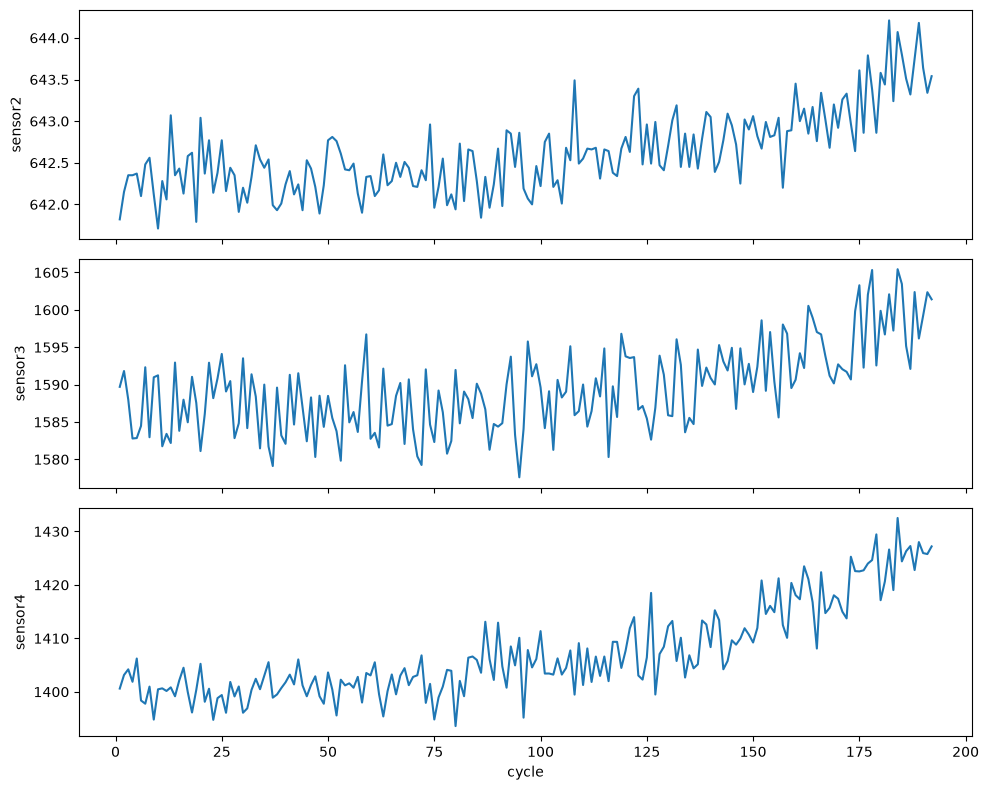

In [10]:
# Plot a few sensors over time for a single engine to visually inspect degradation trends.
engine_1 = train[train['unit'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(engine_1['cycle'], engine_1['sensor2'])
axes[0].set_ylabel('sensor2')

axes[1].plot(engine_1['cycle'], engine_1['sensor3'])
axes[1].set_ylabel('sensor3')

axes[2].plot(engine_1['cycle'], engine_1['sensor4'])
axes[2].set_ylabel('sensor4')
axes[2].set_xlabel('cycle')

plt.tight_layout()
plt.show()

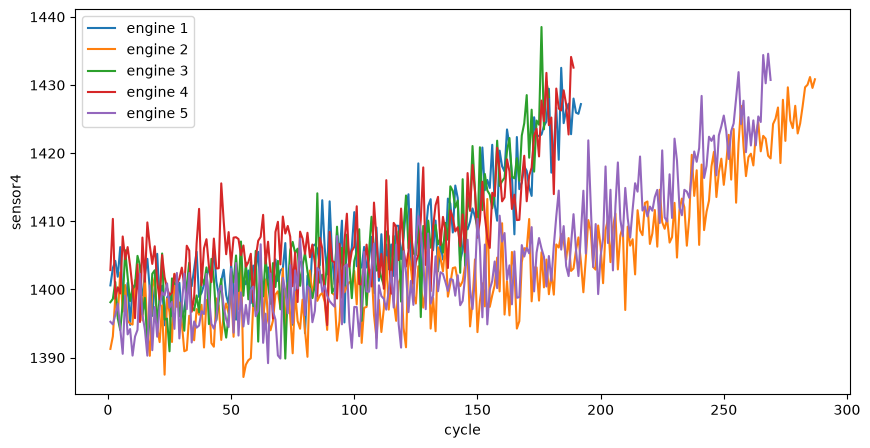

In [11]:
# Overlay sensor4 trajectories for multiple engines to check if the upward trend is consistent
# across engines, not just an artifact of engine 1.
fig, ax = plt.subplots(figsize=(10, 5))

for engine_id in [1, 2, 3, 4, 5]:
    engine_data = train[train['unit'] == engine_id]
    ax.plot(engine_data['cycle'], engine_data['sensor4'], label=f'engine {engine_id}')

ax.set_xlabel('cycle')
ax.set_ylabel('sensor4')
ax.legend()
plt.show()

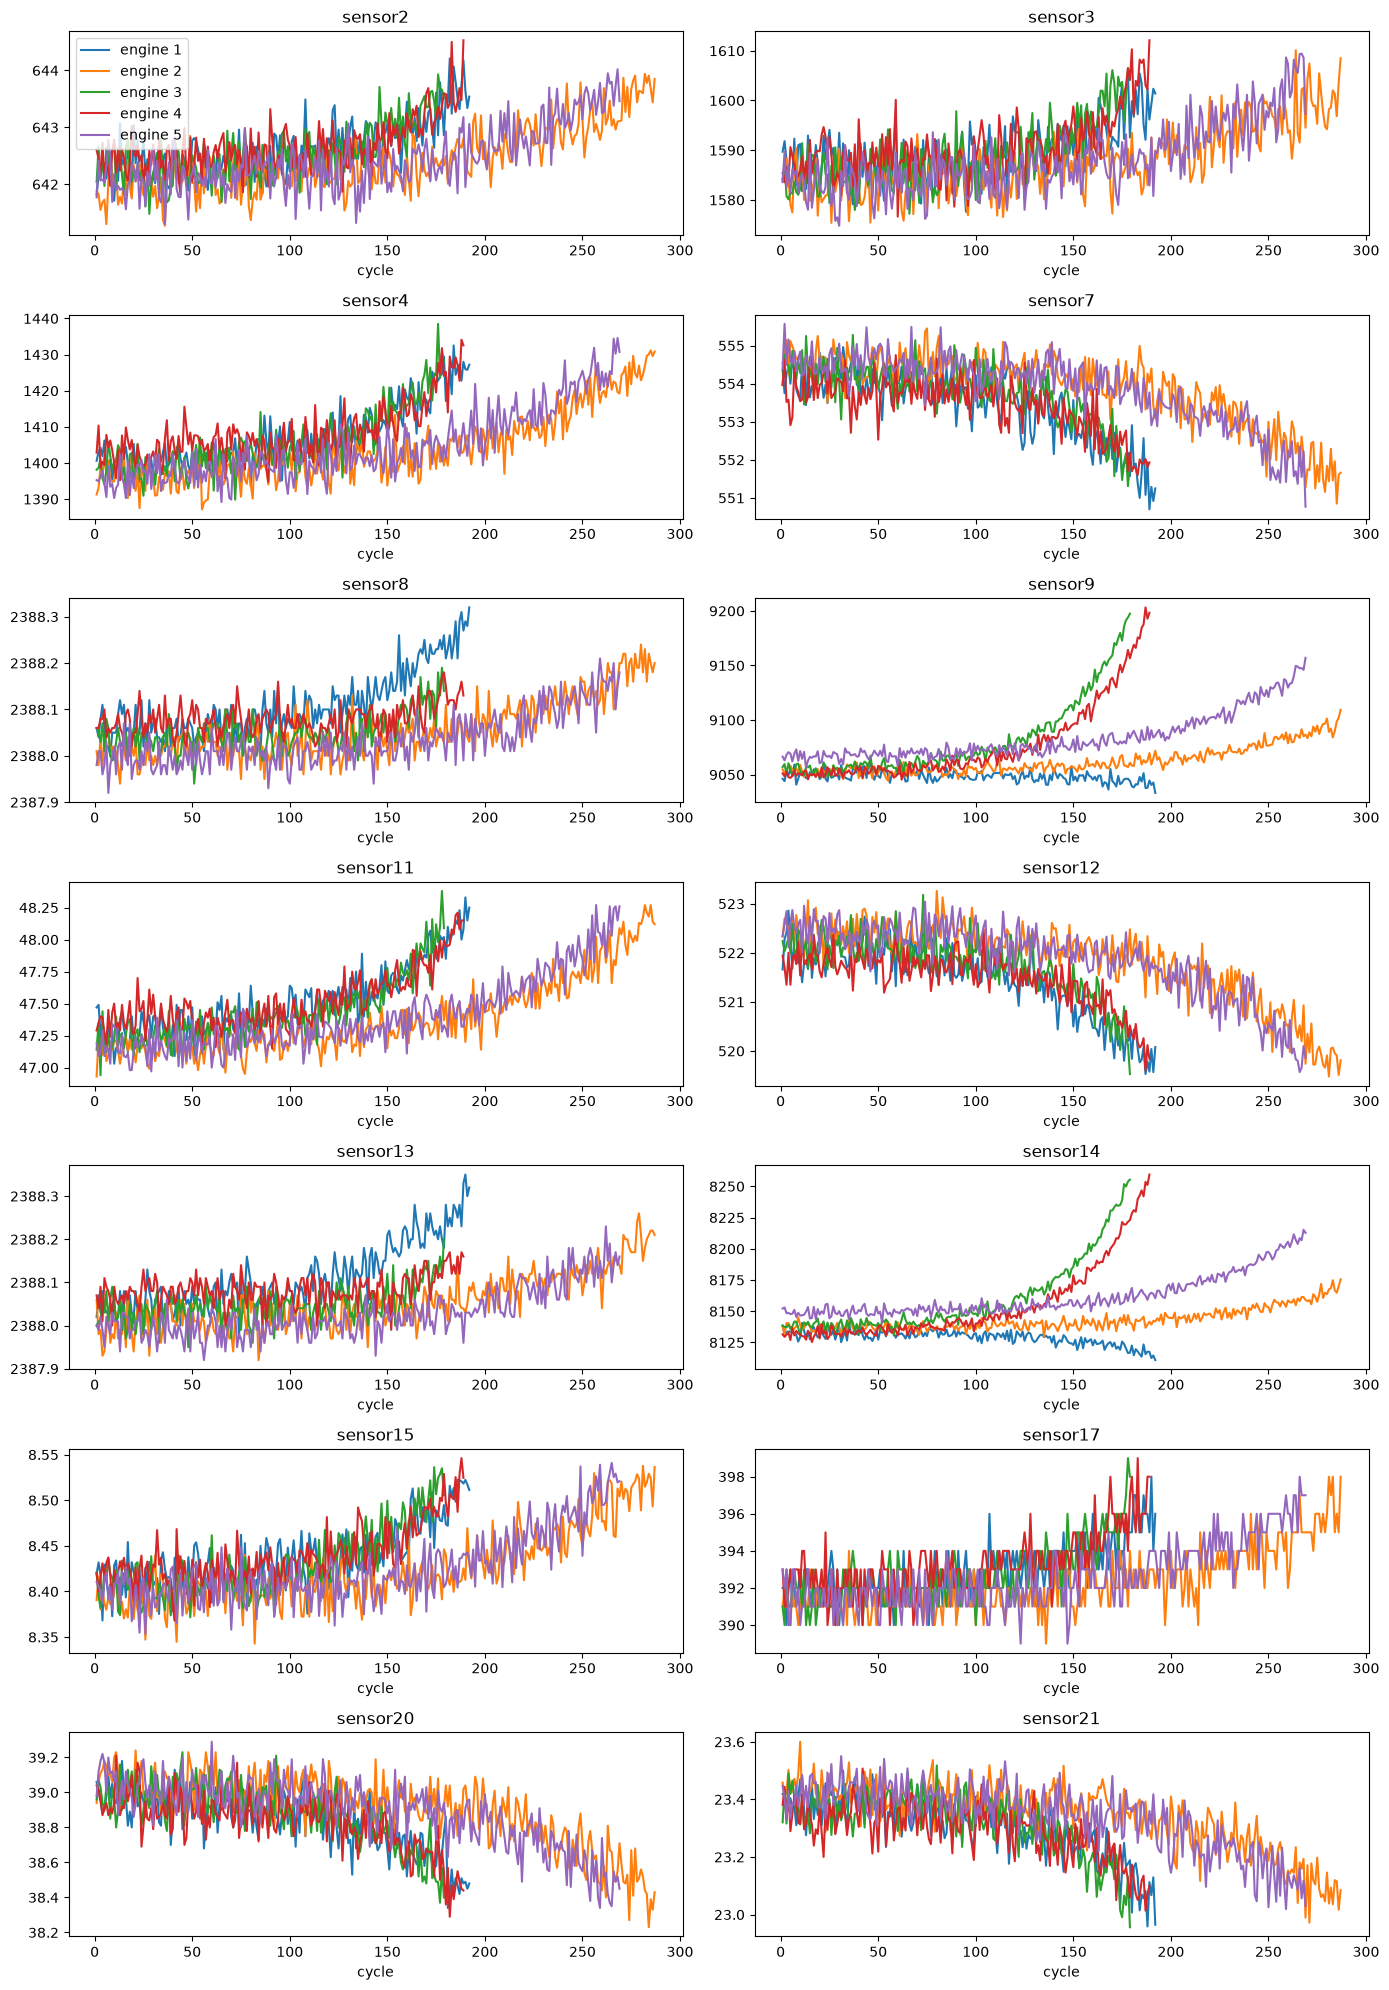

In [12]:
# Plot all 14 useful sensors in a grid, overlaying the same 5 engines on each,
# to compare degradation trends across sensors at once.
engine_ids = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(7, 2, figsize=(14, 20))
axes = axes.flatten()

for i, sensor in enumerate(useful_sensors):
    for engine_id in engine_ids:
        engine_data = train[train['unit'] == engine_id]
        axes[i].plot(engine_data['cycle'], engine_data[sensor], label=f'engine {engine_id}')
    axes[i].set_title(sensor)
    axes[i].set_xlabel('cycle')

axes[0].legend()
plt.tight_layout()
plt.show()

In [13]:
# Try the early-vs-late window comparison on a single engine first, to understand the logic
# before applying it to all 100 engines.
engine_3 = train[train['unit'] == 3]

early_window = engine_3.head(10)
late_window = engine_3.tail(10)

print("Early sensor9 mean:", early_window['sensor9'].mean())
print("Late sensor9 mean:", late_window['sensor9'].mean())

Early sensor9 mean: 9055.542
Late sensor9 mean: 9179.498000000001


In [14]:
# For each sensor, check across all 100 engines whether the late-window mean is higher
# than the early-window mean. This gives a consistency percentage per sensor.
results = []

for sensor in useful_sensors:
    increased_count = 0
    for engine_id in train['unit'].unique():
        engine_data = train[train['unit'] == engine_id]
        early_mean = engine_data[sensor].head(10).mean()
        late_mean = engine_data[sensor].tail(10).mean()
        if late_mean > early_mean:
            increased_count += 1
    results.append({'sensor': sensor, 'pct_increased': increased_count})

results_df = pd.DataFrame(results)
results_df['pct_increased'] = results_df['pct_increased']  # out of 100 engines
print(results_df.sort_values('pct_increased', ascending=False))

      sensor  pct_increased
0    sensor2            100
1    sensor3            100
2    sensor4            100
4    sensor8            100
6   sensor11            100
8   sensor13            100
10  sensor15            100
11  sensor17            100
5    sensor9             70
9   sensor14             57
3    sensor7              0
7   sensor12              0
12  sensor20              0
13  sensor21              0


In [16]:
print(train.isnull().sum().sum())

0


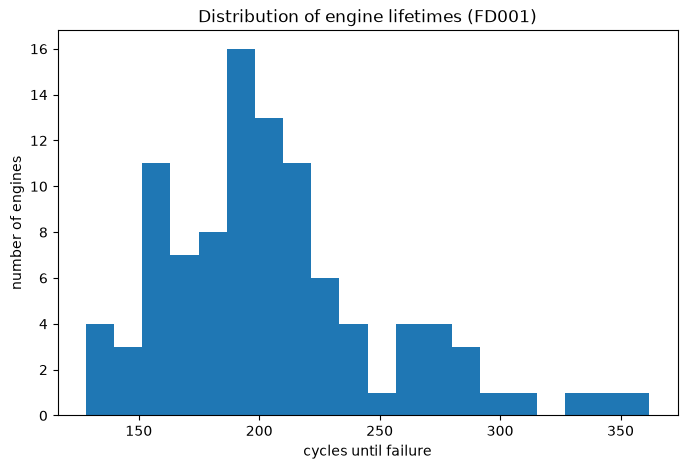

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [17]:
# Distribution of engine lifetimes (max cycle per engine)
lifetimes = train.groupby('unit')['cycle'].max()

plt.figure(figsize=(8, 5))
plt.hist(lifetimes, bins=20)
plt.xlabel('cycles until failure')
plt.ylabel('number of engines')
plt.title('Distribution of engine lifetimes (FD001)')
plt.show()

print(lifetimes.describe())

In [18]:
# Verify readme's claim that FD001 has only one operating condition
print(train[['op1', 'op2', 'op3']].describe())

                op1           op2      op3
count  20631.000000  20631.000000  20631.0
mean      -0.000009      0.000002    100.0
std        0.002187      0.000293      0.0
min       -0.008700     -0.000600    100.0
25%       -0.001500     -0.000200    100.0
50%        0.000000      0.000000    100.0
75%        0.001500      0.000300    100.0
max        0.008700      0.000600    100.0


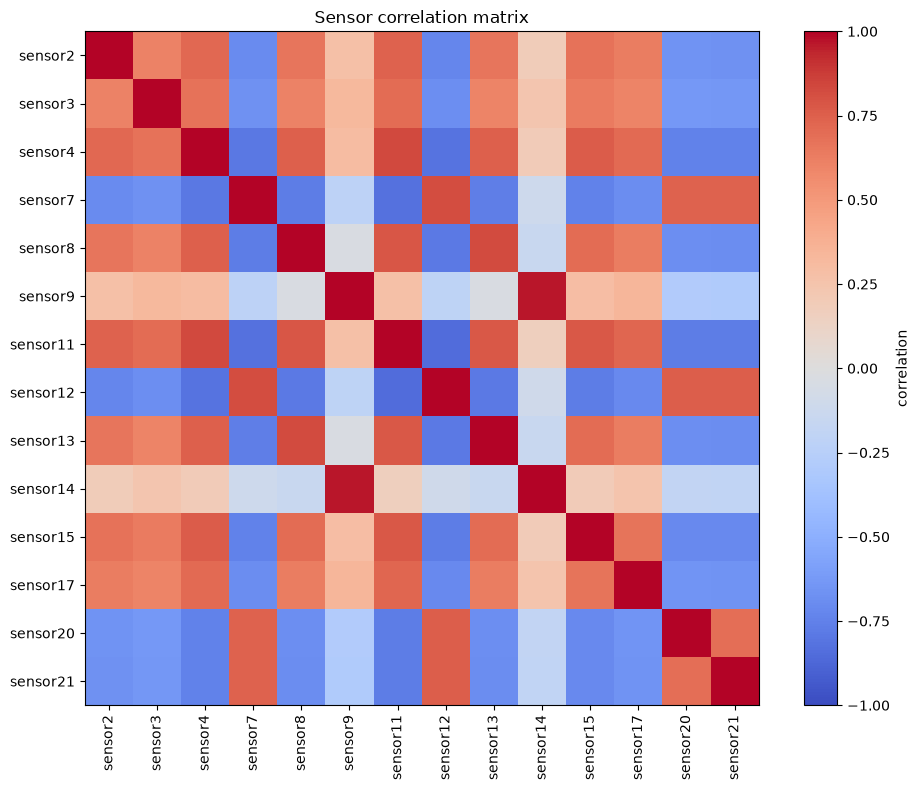

In [19]:
# Correlation matrix of the 14 useful sensors, to check for redundant sensors
correlation_matrix = train[useful_sensors].corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(useful_sensors)), useful_sensors, rotation=90)
plt.yticks(range(len(useful_sensors)), useful_sensors)
plt.title('Sensor correlation matrix')
plt.tight_layout()
plt.show()

In [20]:
# Quantify the sensor9-sensor14 correlation seen in the heatmap
print("sensor9 vs sensor14 correlation:", correlation_matrix.loc['sensor9', 'sensor14'])

sensor9 vs sensor14 correlation: 0.9631566003059777


**Correlation finding:** sensor9 (Nc - physical core speed) and sensor14 (NRc - corrected core speed) 
show a 0.96 correlation, since NRc is a normalized version of Nc and operating conditions are 
constant in FD001. This creates multicollinearity, which could affect Linear Regression coefficient 
stability but is not a concern for tree-based models (Random Forest, XGBoost) or LSTM. Both sensors 
are kept for now; this will be revisited if Linear Regression results look unstable.